# Exploratory Data Analysis (EDA)

This notebook conducts a thorough Exploratory Data Analysis (EDA) on the aggregated and labeled Bitcoin historical + live data. We inspect price trends, return distributions, crash occurrences, hourly/weekly patterns, volume spikes, and volatility profiles.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries loaded successfully!")

In [11]:
df = pd.read_csv("D:/Data Science/ML_Projects/Production_ready_ML_project/data/processed/btc_labeled.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Fix 1: Drop useless columns
df = df.drop(columns=[
    'num_trades', 'buy_volume',
    'sell_volume', 'buy_sell_ratio'
], errors='ignore')

# Fix 2: Use volume_btc, fix zeros with forward fill
df['volume'] = df['volume_btc'].replace(0, np.nan)
df['volume'] = df['volume'].ffill().bfill()
df = df.drop(columns=['volume_btc'], errors='ignore')

In [12]:
df

,timestamp,open,high,low,close,volume,future_return,crash
0,2026-05-16 00:15:00,79133.320312,79133.320312,79104.312500,79106.062500,227.280762,0.000120,0
1,2026-05-16 00:20:00,79106.046875,79162.187500,79106.046875,79134.000000,227.280762,0.000427,0
2,2026-05-16 00:25:00,79133.992188,79139.992188,79115.453125,79126.812500,227.280762,-0.000283,0
3,2026-05-16 00:30:00,79130.242188,79168.492188,79106.210938,79115.539062,227.280762,-0.000145,0
4,2026-05-16 00:35:00,79097.257812,79169.812500,79097.257812,79167.828125,227.280762,-0.001399,0
...,...,...,...,...,...,...,...,...
17216,2026-07-14 19:55:00,63828.700000,63915.070000,63794.000000,63915.060000,134.368445,0.001736,0
17217,2026-07-14 20:00:00,63915.070000,63968.000000,63858.260000,63965.980000,134.368445,-0.000003,0
17218,2026-07-14 20:05:00,63965.980000,64057.820000,63946.160000,64014.010000,134.368445,0.000000,0
17219,2026-07-14 20:10:00,64014.010000,64088.880000,63985.260000,64025.990000,134.368445,0.000000,0


In [13]:
# Load Labeled Data
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df['timestamp'].min()} to {df['timestamp'].max()}")
display(df.head())

Dataset Shape: (17221, 8)
Date Range: 2026-05-16 00:15:00 to 2026-07-14 20:15:00


,timestamp,open,high,low,close,volume,future_return,crash
0,2026-05-16 00:15:00,79133.320312,79133.320312,79104.312500,79106.062500,227.280762,0.000120,0
1,2026-05-16 00:20:00,79106.046875,79162.187500,79106.046875,79134.000000,227.280762,0.000427,0
2,2026-05-16 00:25:00,79133.992188,79139.992188,79115.453125,79126.812500,227.280762,-0.000283,0
3,2026-05-16 00:30:00,79130.242188,79168.492188,79106.210938,79115.539062,227.280762,-0.000145,0
4,2026-05-16 00:35:00,79097.257812,79169.812500,79097.257812,79167.828125,227.280762,-0.001399,0


## Section 1: Price and Returns Analysis

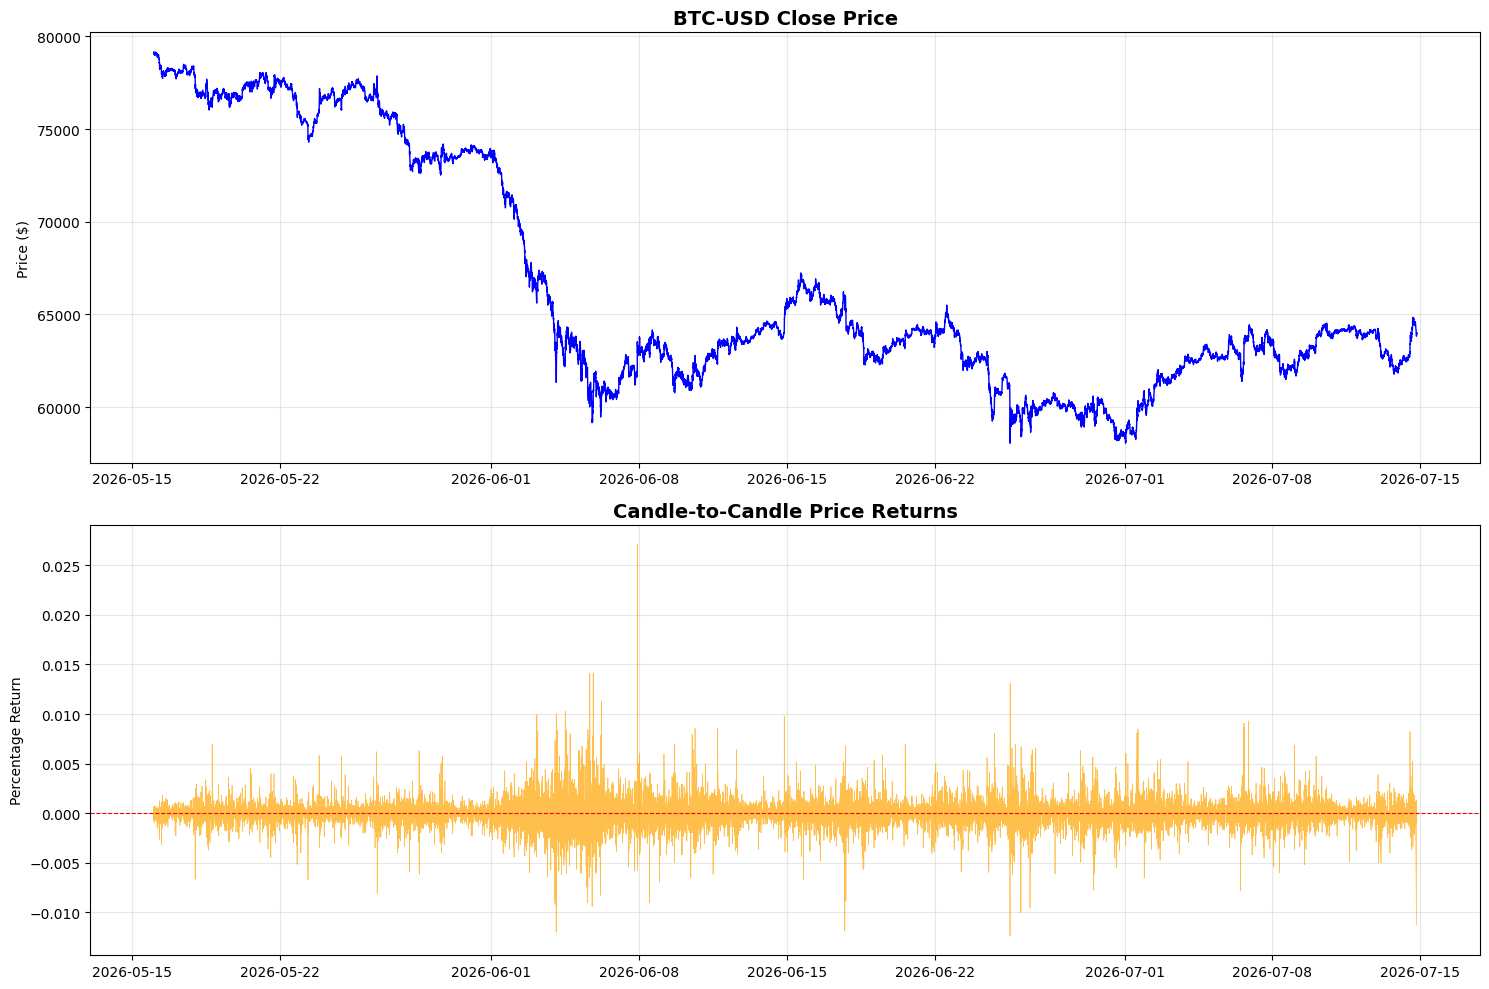

In [14]:
# Compute 1-minute simple returns
df['returns'] = df['close'].pct_change()

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Close Price
axes[0].plot(df['timestamp'], df['close'], color='blue', linewidth=1)
axes[0].set_title('BTC-USD Close Price', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].grid(True, alpha=0.3)

# Plot 2: Returns
axes[1].plot(df['timestamp'], df['returns'], color='orange', linewidth=0.5, alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=0.8)
axes[1].set_title('Candle-to-Candle Price Returns', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Percentage Return')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 2: Crash Event Distributions

Let's see how many crashes (`crash == 1`) are flagged in the dataset and check the class imbalance ratio.

CRASH RATIO DIAGNOSTICS
Total candles: 17,221
Crash candles: 367
Normal candles: 16,854
Crash Rate: 2.1311%


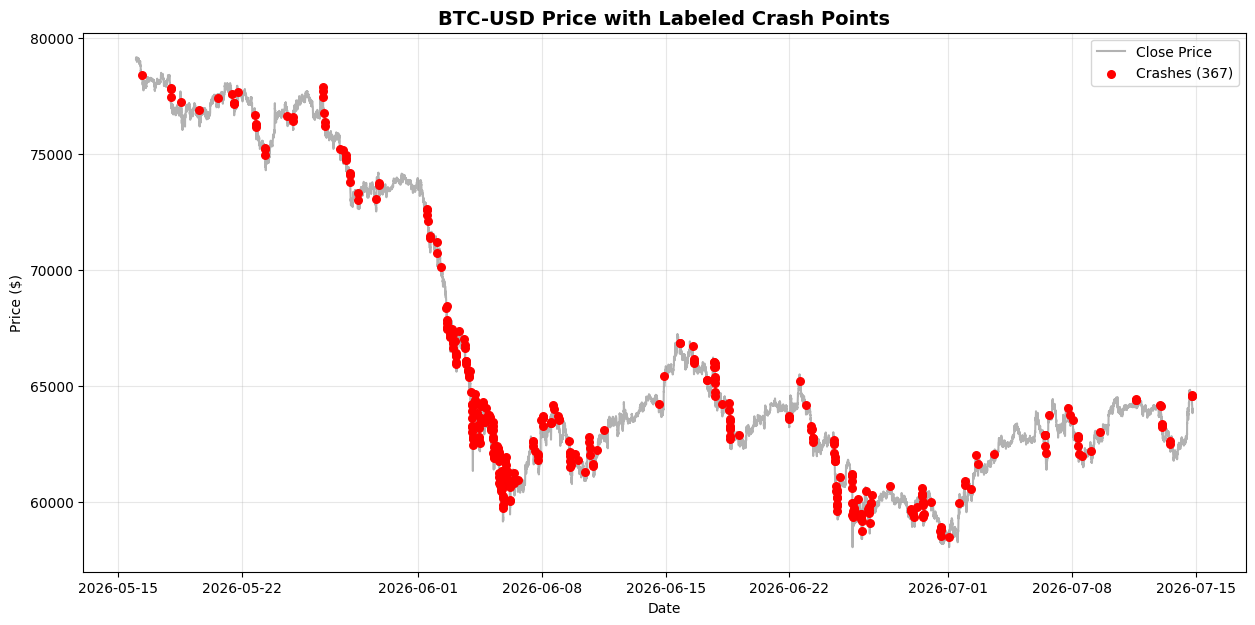

In [15]:
crash_count = df['crash'].sum()
total_samples = len(df)
crash_rate = (crash_count / total_samples) * 100

print("=" * 50)
print("CRASH RATIO DIAGNOSTICS")
print("=" * 50)
print(f"Total candles: {total_samples:,}")
print(f"Crash candles: {crash_count:,}")
print(f"Normal candles: {total_samples - crash_count:,}")
print(f"Crash Rate: {crash_rate:.4f}%")
print("=" * 50)

# Plot crash markers on price series
plt.figure(figsize=(15, 7))
plt.plot(df['timestamp'], df['close'], label='Close Price', color='gray', alpha=0.6)

crashes = df[df['crash'] == 1]
if not crashes.empty:
    plt.scatter(crashes['timestamp'], crashes['close'], color='red', label=f'Crashes ({len(crashes)})', s=30, zorder=5)

plt.title('BTC-USD Price with Labeled Crash Points', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Section 3: Time-Based (Temporal) Patterns

Do crashes occur more frequently during specific hours of the day or days of the week? (Note: Timestamps are in UTC).

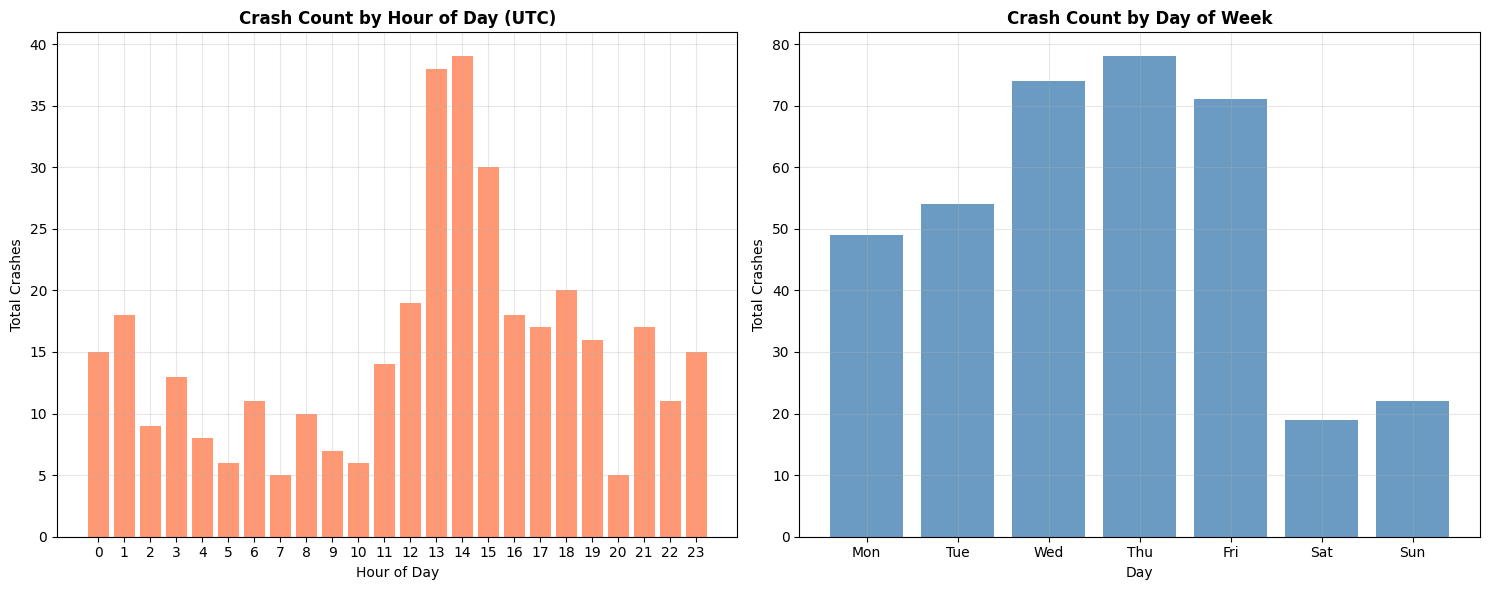

In [16]:
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Crash counts by hour of day
hourly_crashes = df.groupby('hour')['crash'].sum()
axes[0].bar(hourly_crashes.index, hourly_crashes.values, color='coral', alpha=0.8)
axes[0].set_title('Crash Count by Hour of Day (UTC)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Total Crashes')
axes[0].set_xticks(range(24))
axes[0].grid(True, alpha=0.3)

# Crash counts by day of week
weekly_crashes = df.groupby('day_of_week')['crash'].sum()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(days, weekly_crashes.values, color='steelblue', alpha=0.8)
axes[1].set_title('Crash Count by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Total Crashes')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##  Section 4: Trading Volume Diagnostics

Let's see if spikes in trading volume correlate with crashes.

C:\Users\Sweety\AppData\Local\Temp\ipykernel_10152\3458617904.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='crash', y='volume_spike', ax=axes[0], palette=['green', 'red'])
C:\Users\Sweety\AppData\Local\Temp\ipykernel_10152\3458617904.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Normal (0)', 'Crash (1)'])


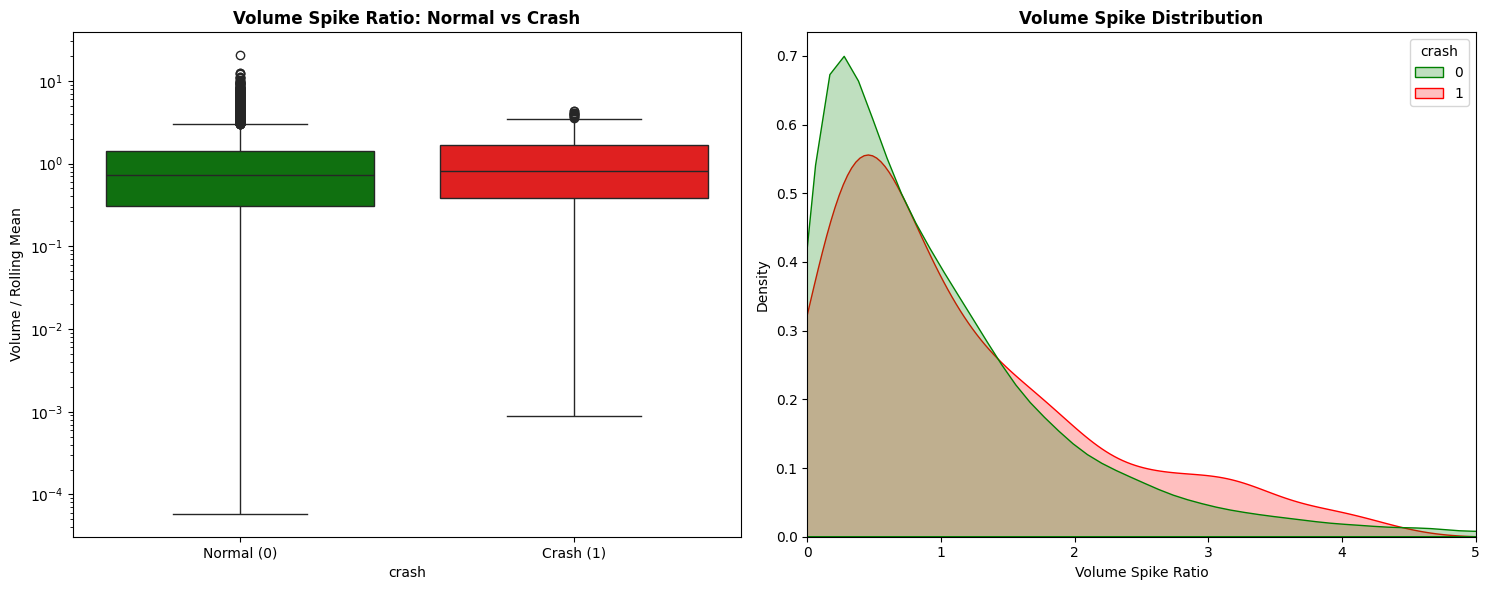

Mean volume spike during normal periods: 1.04
Mean volume spike during crash periods: 1.13


In [17]:
# Normalize volume using a rolling 30-period mean to detect spikes
df['volume_ma_30'] = df['volume'].rolling(window=30, min_periods=1).mean()
df['volume_spike'] = df['volume'] / (df['volume_ma_30'] + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot comparing volume spikes in normal vs crash periods
sns.boxplot(data=df, x='crash', y='volume_spike', ax=axes[0], palette=['green', 'red'])
axes[0].set_title('Volume Spike Ratio: Normal vs Crash', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Normal (0)', 'Crash (1)'])
axes[0].set_ylabel('Volume / Rolling Mean')
axes[0].set_yscale('log') # Log scale for better visibility of outliers

# Distribution plot
sns.kdeplot(data=df, x='volume_spike', hue='crash', ax=axes[1], fill=True, common_norm=False, palette=['green', 'red'])
axes[1].set_title('Volume Spike Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Volume Spike Ratio')
axes[1].set_xlim(0, 5)

plt.tight_layout()
plt.show()

print(f"Mean volume spike during normal periods: {df[df['crash']==0]['volume_spike'].mean():.2f}")
print(f"Mean volume spike during crash periods: {df[df['crash']==1]['volume_spike'].mean():.2f}")

## Section 5: Volatility Signatures

Let's calculate a rolling standard deviation of price returns to analyze volatility characteristics.

C:\Users\Sweety\AppData\Local\Temp\ipykernel_10152\2033026873.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='crash', y='volatility_15', ax=axes[0], palette=['green', 'red'])
C:\Users\Sweety\AppData\Local\Temp\ipykernel_10152\2033026873.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Normal (0)', 'Crash (1)'])


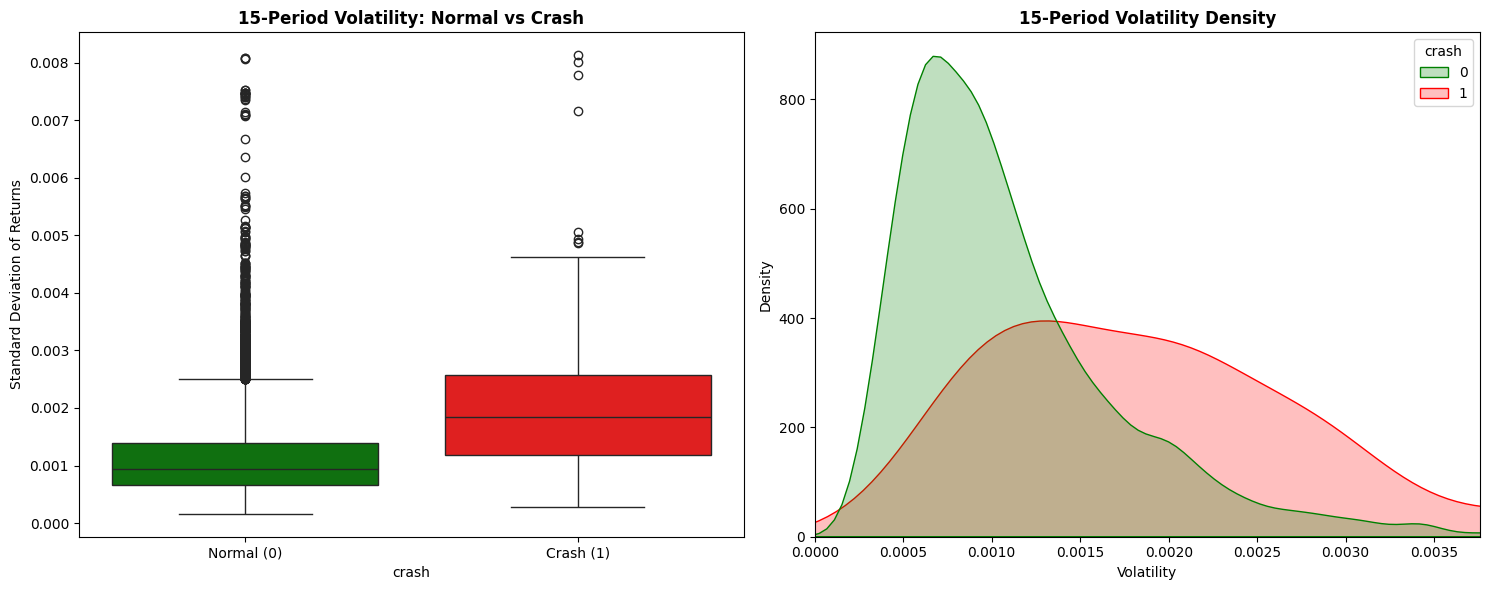

Average 15-period volatility (Normal): 0.1132%
Average 15-period volatility (Crash): 0.2004%


In [18]:
# Compute rolling 5-period and 15-period volatility
df['volatility_5'] = df['returns'].rolling(window=5, min_periods=1).std()
df['volatility_15'] = df['returns'].rolling(window=15, min_periods=1).std()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df, x='crash', y='volatility_15', ax=axes[0], palette=['green', 'red'])
axes[0].set_title('15-Period Volatility: Normal vs Crash', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Normal (0)', 'Crash (1)'])
axes[0].set_ylabel('Standard Deviation of Returns')

sns.kdeplot(data=df, x='volatility_15', hue='crash', ax=axes[1], fill=True, common_norm=False, palette=['green', 'red'])
axes[1].set_title('15-Period Volatility Density', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Volatility')
axes[1].set_xlim(0, df['volatility_15'].quantile(0.99)) # Clip outliers for visibility

plt.tight_layout()
plt.show()

print(f"Average 15-period volatility (Normal): {df[df['crash']==0]['volatility_15'].mean()*100:.4f}%")
print(f"Average 15-period volatility (Crash): {df[df['crash']==1]['volatility_15'].mean()*100:.4f}%")

## Section 6: Base Feature Correlations

Let's check the linear correlation of our raw engineered metrics with the target `crash` label.

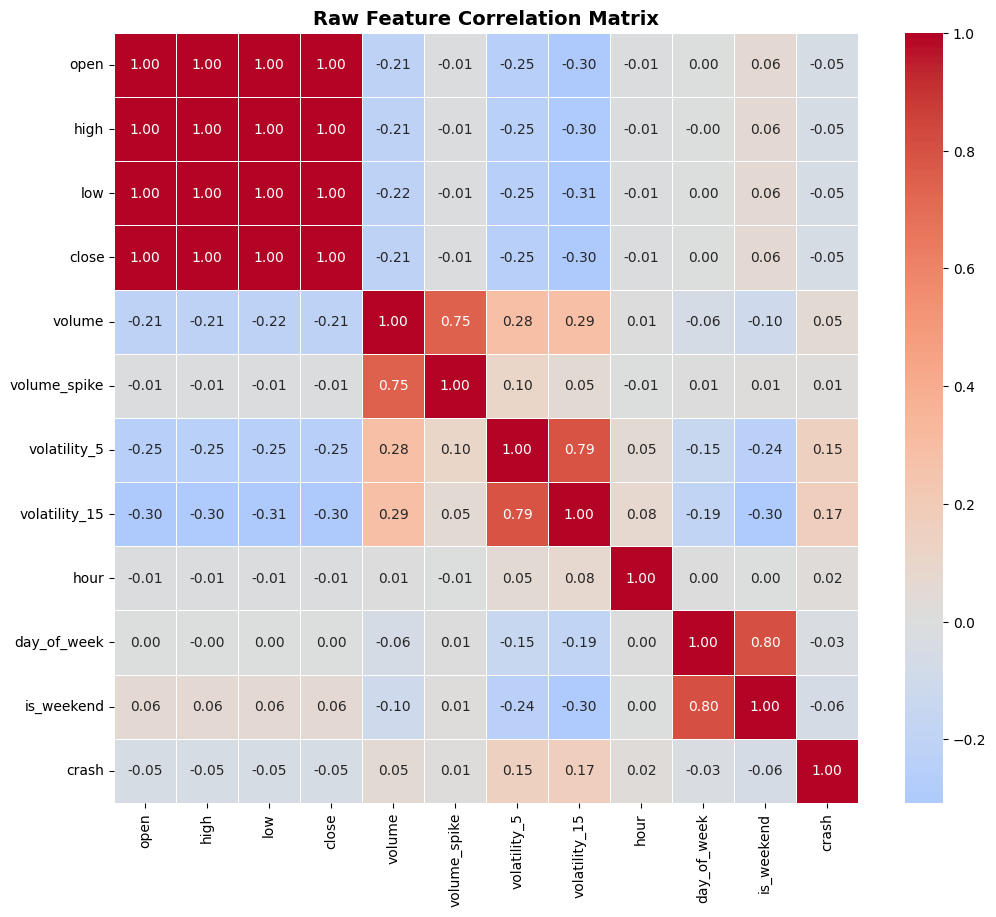

In [19]:
corr_cols = ['open', 'high', 'low', 'close', 'volume', 'volume_spike', 'volatility_5', 'volatility_15', 'hour', 'day_of_week', 'is_weekend', 'crash']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', center=0, linewidths=0.5)
plt.title('Raw Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()

In [20]:
print('=== WHICH PRICE WINDOW PREDICTS CRASH? ===')
for candles in [1, 3, 6, 12, 24]:
    minutes = candles * 5
    df[f'pc_{candles}'] = df['close'].pct_change(candles)
    corr = abs(df[f'pc_{candles}'].corr(df['crash']))
    print(f'{minutes:4d} min ({candles:2d} candles): correlation = {corr:.4f}')

=== WHICH PRICE WINDOW PREDICTS CRASH? ===
   5 min ( 1 candles): correlation = 0.0079
  15 min ( 3 candles): correlation = 0.0260
  30 min ( 6 candles): correlation = 0.0300
  60 min (12 candles): correlation = 0.0380
 120 min (24 candles): correlation = 0.0587


In [21]:
print('=== CRASH RATE BY HOUR ===')
hourly = df.groupby('hour')['crash'].mean() * 100
print(hourly.round(2).to_string())
print(f'\nHighest risk: {hourly.idxmax()}:00 UTC ({hourly.max():.2f}%)')
print(f'Lowest risk:  {hourly.idxmin()}:00 UTC ({hourly.min():.2f}%)')
print(f'\n→ Hour of day matters: {hourly.max()/hourly.min():.1f}x difference')

=== CRASH RATE BY HOUR ===
hour
0     2.09
1     2.50
2     1.25
3     1.81
4     1.11
5     0.83
6     1.53
7     0.69
8     1.39
9     0.97
10    0.83
11    1.94
12    2.64
13    5.28
14    5.42
15    4.17
16    2.50
17    2.36
18    2.79
19    2.25
20    0.70
21    2.40
22    1.55
23    2.12

Highest risk: 14:00 UTC (5.42%)
Lowest risk:  7:00 UTC (0.69%)

→ Hour of day matters: 7.8x difference
